# Taller 03: Problemas de Satisfacción de Restricciones

In [ ]:
import random
import time
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

## 1. Definición del grafo

El grafo puede obtenerse de dos formas:

1. **Generado aleatoriamente**: se construye una matriz de adyacencias simétrica NxN con una probabilidad de arista dada.
2. **Leído de un archivo de texto plano (.txt)**: cada línea del archivo contiene una fila de la matriz, con los valores separados por espacios (0 o 1).

In [ ]:
def generar_matriz_aleatoria(n, prob_arista=0.3, semilla=None):
    """
    Genera una matriz de adyacencias simétrica NxN de forma aleatoria.

    Parámetros:
        n (int): número de nodos (N < 21).
        prob_arista (float): probabilidad de que exista una arista entre dos nodos.
        semilla (int, opcional): semilla para reproducibilidad.

    Retorna:
        list[list[int]]: matriz de adyacencias simétrica con diagonal en cero.
    """
    if n >= 21:
        raise ValueError("N debe ser menor a 21")
    if semilla is not None:
        random.seed(semilla)
    matriz = [[0] * n for _ in range(n)]
    for i in range(n):
        for j in range(i + 1, n):
            if random.random() < prob_arista:
                matriz[i][j] = 1
                matriz[j][i] = 1
    return matriz


def leer_matriz_desde_archivo(ruta_archivo):
    """
    Lee una matriz de adyacencias simétrica desde un archivo de texto plano (.txt).
    Cada línea del archivo debe contener una fila de la matriz con valores
    (0 o 1) separados por espacios.

    Parámetros:
        ruta_archivo (str): ruta del archivo .txt

    Retorna:
        list[list[int]]: matriz de adyacencias.
    """
    matriz = np.loadtxt(ruta_archivo, dtype=int)
    matriz = matriz.tolist()
    n = len(matriz)
    if n >= 21:
        raise ValueError("N debe ser menor a 21")
    # Validación de simetría
    for i in range(n):
        for j in range(n):
            if matriz[i][j] != matriz[j][i]:
                raise ValueError("La matriz leída no es simétrica")
    return matriz


def guardar_matriz_en_archivo(matriz, ruta_archivo):
    """Guarda una matriz de adyacencias en un archivo de texto plano (.txt)."""
    np.savetxt(ruta_archivo, np.array(matriz, dtype=int), fmt="%d")

In [ ]:
class EstadisticasBusqueda:
    """Clase simple para llevar estadísticas de la búsqueda (nodos explorados, backtracks)."""
    def __init__(self):
        self.nodos_explorados = 0
        self.backtracks = 0

    def reiniciar(self):
        self.nodos_explorados = 0
        self.backtracks = 0


def es_consistente(var, valor, asignacion, matriz_adj):
    """Verifica que asignar `valor` a `var` no viole restricciones con vecinos ya asignados."""
    n = len(matriz_adj)
    for otro in range(n):
        if matriz_adj[var][otro] == 1 and otro in asignacion:
            if asignacion[otro] == valor:
                return False
    return True


def forward_checking(var, valor, dominios, matriz_adj, asignacion):
    """
    Poda hacia adelante (Forward Checking).
    Elimina `valor` de los dominios de los vecinos de `var` que aún no han sido asignados.
    Si algún dominio queda vacío, deshace los cambios y retorna None (fallo).
    En caso contrario retorna la lista de cambios realizados (para poder deshacerlos luego).
    """
    eliminados = []
    n = len(matriz_adj)
    for vecino in range(n):
        if matriz_adj[var][vecino] == 1 and vecino not in asignacion:
            if valor in dominios[vecino]:
                dominios[vecino].remove(valor)
                eliminados.append((vecino, valor))
                if len(dominios[vecino]) == 0:
                    restaurar_dominios(dominios, eliminados)
                    return None
    return eliminados


def restaurar_dominios(dominios, eliminados):
    """Deshace las eliminaciones realizadas por forward_checking (usado al retroceder)."""
    for (vecino, valor) in eliminados:
        dominios[vecino].add(valor)


def seleccionar_variable_dinamica(asignacion, dominios, matriz_adj):
    """
    Ordenamiento Dinámico (DO): selecciona la próxima variable a asignar.
    Heurística MRV (Minimum Remaining Values): variable con el dominio más pequeño.
    Desempate mediante heurística de grado: variable con más conexiones hacia
    otras variables no asignadas.
    """
    n = len(matriz_adj)
    no_asignadas = [v for v in range(n) if v not in asignacion]
    tam_min = min(len(dominios[v]) for v in no_asignadas)
    candidatas = [v for v in no_asignadas if len(dominios[v]) == tam_min]
    if len(candidatas) == 1:
        return candidatas[0]

    def grado(v):
        return sum(1 for u in no_asignadas if u != v and matriz_adj[v][u] == 1)

    return max(candidatas, key=grado)


def backtrack(asignacion, dominios, matriz_adj, stats):
    """Búsqueda recursiva BT + FC + DO."""
    stats.nodos_explorados += 1
    n = len(matriz_adj)

    if len(asignacion) == n:
        return dict(asignacion)

    var = seleccionar_variable_dinamica(asignacion, dominios, matriz_adj)

    for valor in sorted(dominios[var]):
        if es_consistente(var, valor, asignacion, matriz_adj):
            asignacion[var] = valor
            eliminados = forward_checking(var, valor, dominios, matriz_adj, asignacion)

            if eliminados is not None:
                resultado = backtrack(asignacion, dominios, matriz_adj, stats)
                if resultado is not None:
                    return resultado
                restaurar_dominios(dominios, eliminados)

            del asignacion[var]
            stats.backtracks += 1

    return None


def bt_fc_do(matriz_adj, k_colores):
    """
    Punto de entrada del algoritmo BT-FC-DO.

    Parámetros:
        matriz_adj (list[list[int]]): matriz de adyacencias simétrica del grafo.
        k_colores (int): número de colores disponibles.

    Retorna:
        (dict|None, EstadisticasBusqueda): la asignación nodo->color si existe solución
        (None si no existe), y las estadísticas de la búsqueda.
    """
    n = len(matriz_adj)
    dominios = {i: set(range(k_colores)) for i in range(n)}
    asignacion = {}
    stats = EstadisticasBusqueda()
    resultado = backtrack(asignacion, dominios, matriz_adj, stats)
    return resultado, stats


def encontrar_coloreado_minimo(matriz_adj, max_colores=None):
    """
    Encuentra el menor número de colores k para el cual existe un coloreado válido,
    probando k = 1, 2, 3, ... de forma incremental.

    Retorna:
        (k, asignacion, stats) del primer k para el cual se encontró solución.
    """
    n = len(matriz_adj)
    if max_colores is None:
        max_colores = n
    for k in range(1, max_colores + 1):
        asignacion, stats = bt_fc_do(matriz_adj, k)
        if asignacion is not None:
            return k, asignacion, stats
    return None, None, None

## 3. Visualización del grafo coloreado

Se utiliza `networkx` para construir el grafo a partir de la matriz de adyacencias y `matplotlib` para dibujarlo, asignando a cada nodo el color correspondiente a la solución encontrada por el algoritmo.

In [ ]:
def dibujar_grafo_coloreado(matriz_adj, asignacion, titulo="Grafo Coloreado (BT-FC-DO)"):
    """
    Dibuja el grafo definido por `matriz_adj`, coloreando cada nodo según `asignacion`
    (diccionario nodo -> índice de color).
    """
    n = len(matriz_adj)
    G = nx.Graph()
    G.add_nodes_from(range(n))
    for i in range(n):
        for j in range(i + 1, n):
            if matriz_adj[i][j] == 1:
                G.add_edge(i, j)

    if asignacion is None:
        print("No se encontró una asignación válida para dibujar.")
        return

    num_colores = max(asignacion.values()) + 1
    paleta = list(mcolors.TABLEAU_COLORS.values())
    if num_colores > len(paleta):
        cmap = plt.cm.get_cmap("hsv", num_colores)
        paleta = [mcolors.to_hex(cmap(i)) for i in range(num_colores)]

    colores_nodos = [paleta[asignacion[nodo]] for nodo in G.nodes()]

    plt.figure(figsize=(7, 6))
    pos = nx.spring_layout(G, seed=42)
    nx.draw(
        G, pos,
        with_labels=True,
        node_color=colores_nodos,
        node_size=650,
        edge_color="gray",
        font_weight="bold",
        font_color="white",
    )
    plt.title(f"{titulo}\n(N={n} nodos, k={num_colores} colores)")
    plt.axis("off")
    plt.show()

## 4. Demostración 1: Grafo generado aleatoriamente

Se genera un grafo aleatorio de $N=12$ nodos y se busca el menor número de colores necesario para colorearlo, usando BT-FC-DO.

Matriz de adyacencias generada:
[[0 0 1 0 1 0 0 1 0 1 0 1]
 [0 0 1 0 0 1 1 0 0 0 0 0]
 [1 1 0 1 0 1 1 1 0 0 1 0]
 [0 0 1 0 0 0 0 1 1 1 0 0]
 [1 0 0 0 0 0 0 0 1 0 0 1]
 [0 1 1 0 0 0 0 0 0 0 1 0]
 [0 1 1 0 0 0 0 1 0 0 1 0]
 [1 0 1 1 0 0 1 0 1 0 0 0]
 [0 0 0 1 1 0 0 1 0 0 0 0]
 [1 0 0 1 0 0 0 0 0 0 0 0]
 [0 0 1 0 0 1 1 0 0 0 0 0]
 [1 0 0 0 1 0 0 0 0 0 0 0]]

Número mínimo de colores encontrado: 3
Asignación (nodo -> color): {2: 0, 0: 1, 7: 2, 3: 1, 6: 1, 1: 2, 5: 1, 8: 0, 4: 2, 10: 2, 11: 0, 9: 0}
Nodos explorados: 13 | Backtracks: 0
Tiempo de ejecución: 0.0002 segundos


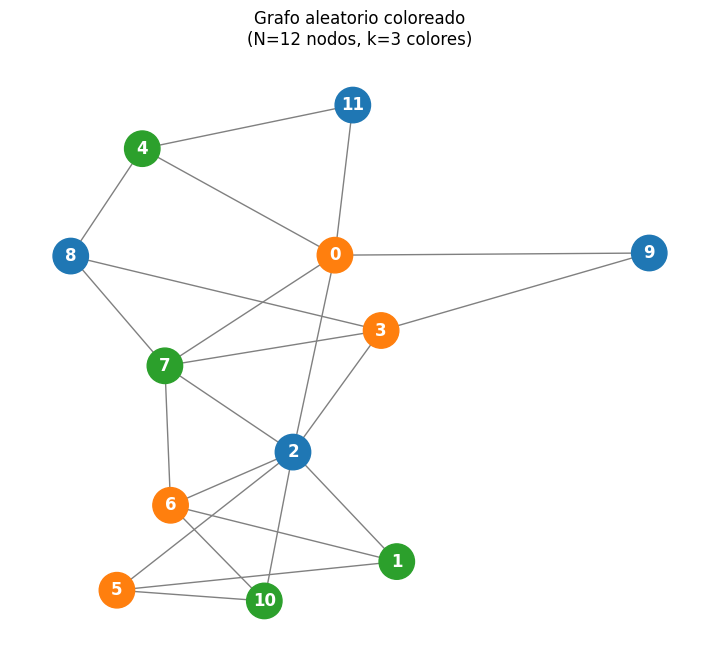

In [ ]:
N = 12
matriz_aleatoria = generar_matriz_aleatoria(N, prob_arista=0.3, semilla=7)

print("Matriz de adyacencias generada:")
print(np.array(matriz_aleatoria))

inicio = time.time()
k_min, asignacion, stats = encontrar_coloreado_minimo(matriz_aleatoria)
fin = time.time()

print(f"\nNúmero mínimo de colores encontrado: {k_min}")
print(f"Asignación (nodo -> color): {asignacion}")
print(f"Nodos explorados: {stats.nodos_explorados} | Backtracks: {stats.backtracks}")
print(f"Tiempo de ejecución: {fin - inicio:.4f} segundos")

dibujar_grafo_coloreado(matriz_aleatoria, asignacion, titulo="Grafo aleatorio coloreado")

## 5. Demostración 2: Grafo leído desde un archivo de texto (.txt)

Se crea un archivo `grafo_ejemplo.txt` de ejemplo con una matriz de adyacencias (equivalente al clásico problema de coloreado del mapa de Australia, con 7 nodos) y se lee desde disco.

> Para usar tu propio grafo, coloca tu archivo `.txt` en la misma carpeta del notebook y cambia la variable `ruta_archivo` por el nombre de tu archivo.

Matriz de adyacencias leída desde archivo:
[[0 1 1 0 0 0 0]
 [1 0 1 1 0 0 0]
 [1 1 0 1 1 0 1]
 [0 1 1 0 1 0 0]
 [0 0 1 1 0 1 1]
 [0 0 0 0 1 0 1]
 [0 0 1 0 1 1 0]]

Número mínimo de colores encontrado: 3
Asignación (nodo -> color): {2: 0, 4: 1, 3: 2, 1: 1, 6: 2, 0: 2, 5: 0}
Nodos explorados: 8 | Backtracks: 0


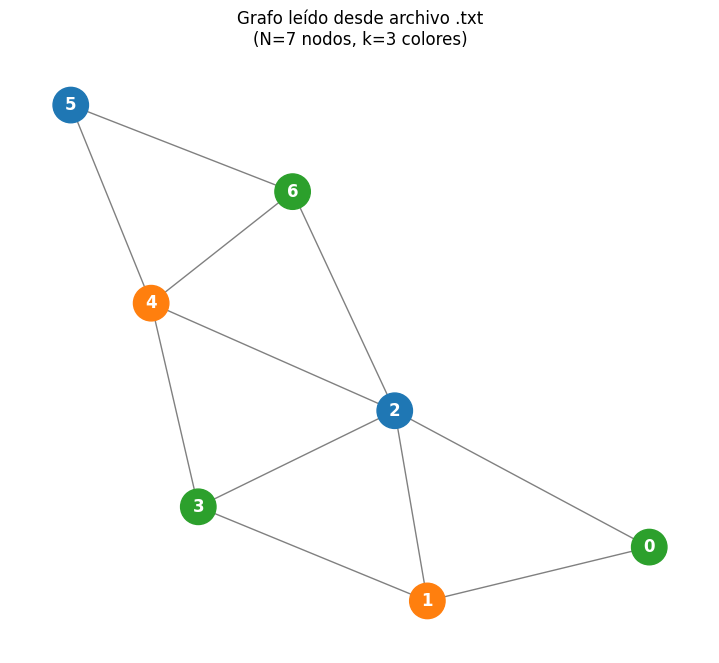

In [ ]:
# Se crea un archivo de ejemplo (7 nodos) para demostrar la lectura desde .txt
matriz_ejemplo = [
    [0, 1, 1, 0, 0, 0, 0],
    [1, 0, 1, 1, 0, 0, 0],
    [1, 1, 0, 1, 1, 0, 1],
    [0, 1, 1, 0, 1, 0, 0],
    [0, 0, 1, 1, 0, 1, 1],
    [0, 0, 0, 0, 1, 0, 1],
    [0, 0, 1, 0, 1, 1, 0],
]
guardar_matriz_en_archivo(matriz_ejemplo, "grafo_ejemplo.txt")

ruta_archivo = "grafo_ejemplo.txt"
matriz_desde_archivo = leer_matriz_desde_archivo(ruta_archivo)

print("Matriz de adyacencias leída desde archivo:")
print(np.array(matriz_desde_archivo))

k_min2, asignacion2, stats2 = encontrar_coloreado_minimo(matriz_desde_archivo)

print(f"\nNúmero mínimo de colores encontrado: {k_min2}")
print(f"Asignación (nodo -> color): {asignacion2}")
print(f"Nodos explorados: {stats2.nodos_explorados} | Backtracks: {stats2.backtracks}")

dibujar_grafo_coloreado(matriz_desde_archivo, asignacion2, titulo="Grafo leído desde archivo .txt")